In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [7]:
df_clean = pd.read_csv(r"C:\Users\HP\Delinquency_Data_analytics_forage\data\processed\cleaned_delinquency_dataset.csv")

In [8]:
df_clean.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [9]:
df_clean.shape

(500, 18)

In [10]:
X = df_clean.drop("Delinquent_Account", axis=1)
y = df_clean["Delinquent_Account"]

print(X.shape)
print(y.value_counts())

(500, 17)
Delinquent_Account
0    420
1     80
Name: count, dtype: int64


In [11]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Employment_Status', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']
Numerical: ['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']


In [12]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [13]:
X.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,Employment_Status_Employed,Employment_Status_Self-employed,...,Month_2_Missed,Month_2_On-time,Month_3_Missed,Month_3_On-time,Month_4_Missed,Month_4_On-time,Month_5_Missed,Month_5_On-time,Month_6_Missed,Month_6_On-time
0,56,165580.0,398.0,0.390502,3,16310.0,0.317396,18,False,False,...,False,False,True,False,False,False,True,False,False,False
1,69,100999.0,493.0,0.312444,6,17401.0,0.196093,0,False,True,...,True,False,False,False,True,False,False,True,False,True
2,46,188416.0,500.0,0.359930,0,13761.0,0.301655,1,False,True,...,False,False,False,False,False,True,True,False,False,False
3,32,101672.0,413.0,0.371400,3,88778.0,0.264794,15,False,False,...,True,False,False,False,True,False,False,False,False,False
4,60,38524.0,487.0,0.234716,2,13316.0,0.510583,11,False,True,...,False,True,True,False,False,False,False,False,False,False


In [14]:
scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [15]:
print(X.shape)

X.head()

(500, 33)


,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,Employment_Status_Employed,Employment_Status_Self-employed,...,Month_2_Missed,Month_2_On-time,Month_3_Missed,Month_3_On-time,Month_4_Missed,Month_4_On-time,Month_5_Missed,Month_5_On-time,Month_6_Missed,Month_6_On-time
0,0.601926,1.112383,-1.067560,-0.512652,0.016453,-1.128719,0.196285,1.395948,False,False,...,False,False,True,False,False,False,True,False,False,False
1,1.405812,-0.142303,-0.503342,-0.909076,1.558879,-1.090449,-1.088351,-1.646069,False,True,...,True,False,False,False,True,False,False,True,False,True
2,-0.016449,1.556043,-0.461768,-0.667913,-1.525974,-1.218132,0.029582,-1.477068,False,True,...,False,False,False,False,False,True,True,False,False,False
3,-0.882173,-0.129228,-0.978473,-0.609661,0.016453,1.413307,-0.360781,0.888945,False,False,...,True,False,False,False,True,False,False,False,False,False
4,0.849275,-1.356073,-0.538977,-1.303824,-0.497690,-1.233742,2.242190,0.212941,False,True,...,False,True,True,False,False,False,False,False,False,False


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print(y_train.value_counts())
print(y_test.value_counts())

Delinquent_Account
0    336
1     64
Name: count, dtype: int64
Delinquent_Account
0    84
1    16
Name: count, dtype: int64


In [18]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [19]:
print(y_train_smote.value_counts())

Delinquent_Account
0    336
1    336
Name: count, dtype: int64


MODEL TRAINING AND EVALUATION



In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [21]:
lr = LogisticRegression(random_state=42, max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

In [22]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train_smote, y_train_smote)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

In [23]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [25]:
def evaluate_model(name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    return {
        "Model": name,
        "Accuracy": round(accuracy, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1 Score": round(f1, 3),
        "ROC AUC": round(roc_auc, 3)
    }

In [26]:
results = []

results.append(
    evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
)

results.append(
    evaluate_model("Decision Tree", y_test, dt_pred, dt_prob)
)

results.append(
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.72,0.167,0.188,0.176,0.557
1,Decision Tree,0.62,0.107,0.188,0.136,0.407
2,Random Forest,0.83,0.333,0.062,0.105,0.481


In [27]:
best_model = rf
best_pred = rf_pred
best_prob = rf_prob

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91        84
           1       0.33      0.06      0.11        16

    accuracy                           0.83       100
   macro avg       0.59      0.52      0.51       100
weighted avg       0.76      0.83      0.78       100



In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

print(cm)

[[82  2]
 [15  1]]


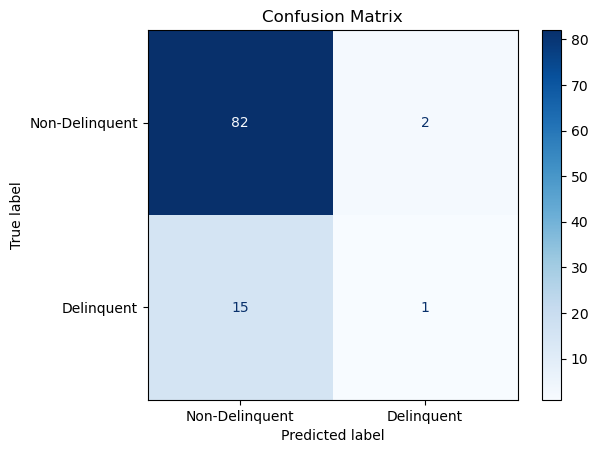

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Delinquent", "Delinquent"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [31]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[81  3]
 [15  1]]
              precision    recall  f1-score   support

           0       0.84      0.96      0.90        84
           1       0.25      0.06      0.10        16

    accuracy                           0.82       100
   macro avg       0.55      0.51      0.50       100
weighted avg       0.75      0.82      0.77       100



In [33]:
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_pred = (rf_prob >= 0.35).astype(int)

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[61 23]
 [11  5]]
              precision    recall  f1-score   support

           0       0.85      0.73      0.78        84
           1       0.18      0.31      0.23        16

    accuracy                           0.66       100
   macro avg       0.51      0.52      0.50       100
weighted avg       0.74      0.66      0.69       100



<Figure size 800x600 with 0 Axes>

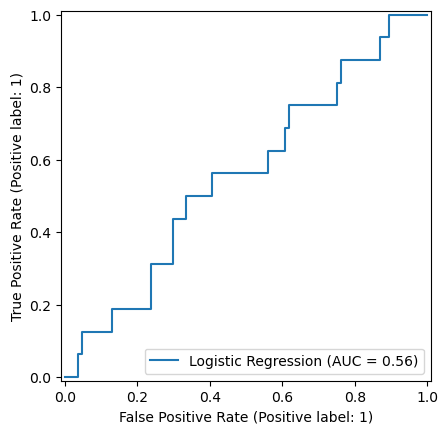

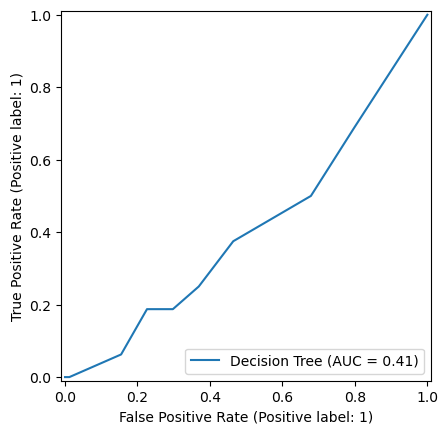

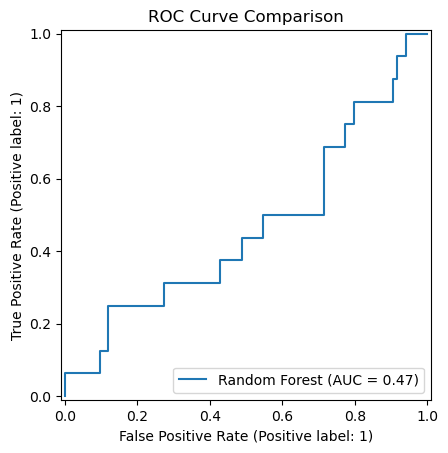

In [35]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(y_test, lr_prob, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, dt_prob, name="Decision Tree")
RocCurveDisplay.from_predictions(y_test, rf_prob, name="Random Forest")

plt.title("ROC Curve Comparison")
plt.show()

In [36]:
results = []

results.append(
    evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
)

results.append(
    evaluate_model("Decision Tree", y_test, dt_pred, dt_prob)
)

results.append(
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.72,0.167,0.188,0.176,0.557
1,Decision Tree,0.62,0.107,0.188,0.136,0.407
2,Random Forest,0.66,0.179,0.312,0.227,0.466


In [37]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Delinquent_Account
0    336
1     64
Name: count, dtype: int64
Delinquent_Account
0    336
1    336
Name: count, dtype: int64


In [38]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,Income,0.077450
0,Age,0.076786
3,Credit_Utilization,0.075113
2,Credit_Score,0.065700
7,Account_Tenure,0.062949
5,Loan_Balance,0.062702
6,Debt_to_Income_Ratio,0.060690
4,Missed_Payments,0.055883
8,Employment_Status_Employed,0.049401
22,Month_1_On-time,0.035074


PREDICTION RESULTS


In [39]:
prediction_results = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": rf_pred,
    "Probability": rf_prob
})

prediction_results.to_csv(
    "prediction_results.csv",
    index=False
)

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [41]:
results_df.to_csv(
    "model_performance.csv",
    index=False
)